In [32]:
from pathlib import Path
import numpy as np

dataset_path = Path("../datasets/test_base_params_300_points_linear_075_noise_025")

str_jpc_config = (dataset_path / "jpc_config.txt").read_text()
str_quantum_parameters = (dataset_path / "quantum_parameters.txt").read_text()
str_encoding = (dataset_path / "encoding.txt").read_text()

print(str_jpc_config)
print(str_quantum_parameters)
print(str_encoding)

JPCConfig(
    DIM_A=10,
    DIM_B=10,
    OMEGA_A=10000.0,
    OMEGA_B=9000.0,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QuantumParameters(
    g_conv=900,
    g_sq=180,
    epsilon_a=170,
    epsilon_b=170,
    delta_a=0,
    delta_b=0
)

Encoding(
    encoding_parameters=('g_sq',),
    encoding_function=Linear()
)



In [33]:
X = np.load(dataset_path / "X.npy")
Y = np.load(dataset_path / "Y.npy")

X.shape, Y.shape

((300, 2), (300, 1))

In [34]:
F_quad = np.load(dataset_path / "f_quad.npy")
F_quad_poly = np.load(dataset_path / "f_quad_poly.npy")
F_probas = np.load(dataset_path / "f_probas.npy")

F_quad.shape, F_quad_poly.shape, F_probas.shape

((300, 80), (300, 280), (300, 80))

In [35]:
nb_batches_train = 200

X_train, X_test = X[:nb_batches_train], X[nb_batches_train:]
Y_train, Y_test = Y[:nb_batches_train], Y[nb_batches_train:]

F_train_quad, F_test_quad = F_quad[:nb_batches_train], F_quad[nb_batches_train:]
F_train_quad_poly, F_test_quad_poly = F_quad_poly[:nb_batches_train], F_quad_poly[nb_batches_train:]
F_train_probas, F_test_probas = F_probas[:nb_batches_train], F_probas[nb_batches_train:]

F_train_quad.shape, F_train_quad_poly.shape, F_train_probas.shape, Y_train.shape

((200, 80), (200, 280), (200, 80), (200, 1))

In [36]:
from lab.config.neural_networks import linear, XS
from zeroth import first_order

config = XS  # try XS
config.summary()

neural_network_quad = first_order.FirstOrderNeuralNetwork(config=config,
                                                          input_dim=F_quad.shape[-1],
                                                          output_dim=1)

neural_network_quad_poly = first_order.FirstOrderNeuralNetwork(config=config,
                                                               input_dim=F_quad_poly.shape[-1],
                                                               output_dim=1)

neural_network_probas = first_order.FirstOrderNeuralNetwork(config=config,
                                                            input_dim=F_probas.shape[-1],
                                                            output_dim=1)


NeuralNetworkConfig(
    name='xs',
    hidden_dims=[
        10
    ],
    activations=[
        ReLU(),
        Sigmoid()
    ]
)


In [37]:
optimizer_config = first_order.FirstOrderAdamConfig(learning_rate=0.005,
                                                    beta1=0.99,
                                                    beta2=0.999,
                                                    epsilon=1e-8)

optimizer_quad = optimizer_config.instantiate()
optimizer_quad_poly = optimizer_config.instantiate()
optimizer_probas = optimizer_config.instantiate()

In [38]:
from zeroth.losses.binary_cross_entropy import BinaryCrossEntropy

loss = BinaryCrossEntropy()

def train_step(_F_quad: np.ndarray, _F_quad_poly: np.ndarray, _F_probas: np.ndarray, _Y: np.ndarray) -> tuple[float, float, float]:
    loss_quad = optimizer_quad.do_descent(neural_network=neural_network_quad,
                                          loss=loss,
                                          X=_F_quad,
                                          Y_true=_Y)

    loss_quad_poly = optimizer_quad_poly.do_descent(neural_network=neural_network_quad_poly,
                                                    loss=loss,
                                                    X=_F_quad_poly,
                                                    Y_true=_Y)

    loss_quad_probas = optimizer_probas.do_descent(neural_network=neural_network_probas,
                                                   loss=loss,
                                                   X=_F_probas,
                                                   Y_true=_Y)

    return loss_quad, loss_quad_poly, loss_quad_probas

X_train = X_train.reshape(-1)

nb_epochs = 1000
losses = np.zeros((3, nb_epochs * nb_batches_train))

# for epoch in range(nb_epochs):
#     # 1. On crée une liste d'indices mélangés pour l'époque courante
#     indices = np.random.permutation(nb_batches_train)
#
#     # 2. On itère sur ces indices mélangés
#     for step, i in enumerate(indices):
#         batch_loss = train_step(_F_quad=F_train_quad[i],
#                                 _F_quad_poly=F_train_quad_poly[i],
#                                 _F_probas=F_train_probas[i],
#                                 _Y=Y_train[i])
#
#         # On sauvegarde la loss à l'étape correspondante (epoch * nb_batches + step)
#         losses[:, epoch * nb_batches_train + step] = batch_loss

for epoch in range(nb_epochs):
    batch_loss = train_step(_F_quad=F_train_quad,
                            _F_quad_poly=F_train_quad_poly,
                            _F_probas=F_train_probas,
                            _Y=Y_train)

    # On sauvegarde la loss à l'étape correspondante (epoch * nb_batches + step)
    losses[:, epoch] = batch_loss

C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\zeroth\plot_losses.py:80: RuntimeWarning: divide by zero encountered in log
  return np.exp(pd.Series(np.log(loss)).ewm(span=window_length, adjust=True).mean())


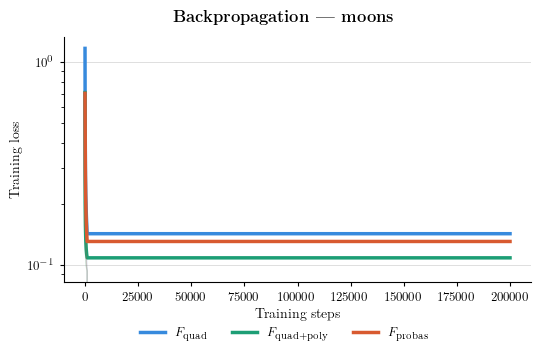

In [39]:
from zeroth.plot_losses import set_style, format_ax, smooth_curve
import matplotlib.pyplot as plt
import numpy as np

set_style()

smooth_fraction = 0.1
labels = [
    r"$F_{\mathrm{quad}}$",
    r"$F_{\mathrm{quad+poly}}$",
    r"$F_{\mathrm{probas}}$",
]

configs = [
    (losses[0],      '#378ADD',  r'$F_{\mathrm{quad}}$'),
    (losses[1], '#1D9E75', r'$F_{\mathrm{quad+poly}}$'),
    (losses[2],    '#D85A30',  r'$F_{\mathrm{probas}}$'),
]

colors  = ["#378ADD", "#1D9E75", "#D85A30"]

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for data, color, label in configs:
    window = int(len(data) * smooth_fraction)

    ax.plot(data, alpha=0.2, linewidth=1.0, color=color)
    smooth = smooth_curve(data, window)
    ax.plot(smooth, label=label, linewidth=2.5, color=color)
# for data, color, ls, label in configs:
#     kde = gaussian_kde(data)
#     ax.plot(x, kde(x), color=color, ls=ls, lw=2, label=label)
#     ax.fill_between(x, kde(x), alpha=0.08, color=color)

format_ax(ax)
ax.set_xlabel("Training steps")
ax.set_ylabel("Training loss")
fig.suptitle(r"\textbf{Backpropagation — moons}",
             fontweight='bold', fontsize=12)

handles, labels_leg = ax.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0), frameon=False, fontsize=9)

plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.2)
plt.show()

In [40]:
Y_pred_quad = neural_network_quad(F_test_quad)
Y_pred_quad_poly = neural_network_quad_poly(F_test_quad_poly)
Y_pred_probas = neural_network_probas(F_test_probas)

Y_pred_quad.shape, Y_test.shape

((100, 1), (100, 1))

In [41]:
Y_pred_01_quad = Y_pred_quad >= 0.5
acc_quad = np.mean(Y_pred_01_quad == Y_test)
print(f"Accuracy quadratures = {acc_quad * 1e2} %")

Y_pred_01_quad_poly = Y_pred_quad_poly >= 0.5
acc_quad_poly = np.mean(Y_pred_01_quad_poly == Y_test)
print(f"Accuracy quadratures poly = {acc_quad_poly * 1e2} %")

Y_pred_01_probas = Y_pred_probas >= 0.5
acc_probas = np.mean(Y_pred_01_probas == Y_test)
print(f"Accuracy probas = {acc_probas * 1e2} %")

Accuracy quadratures = 95.0 %
Accuracy quadratures poly = 97.0 %
Accuracy probas = 97.0 %


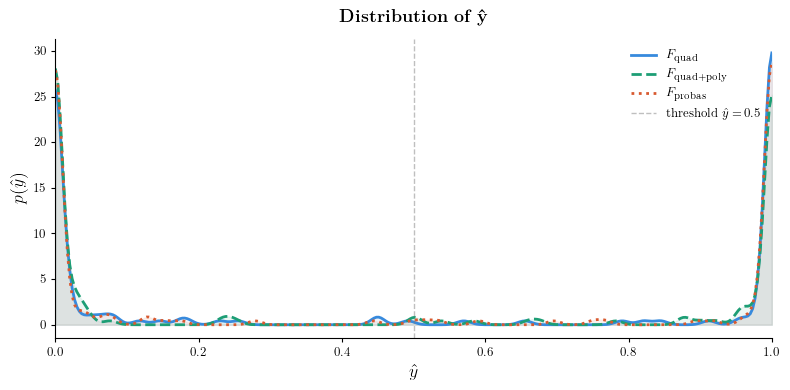

In [42]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
# On limite strictement l'axe des x de 0 à 1
x = np.linspace(0, 1, 300)

configs = [
    (Y_pred_quad[:, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[:, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[:, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    # 1. MÉTHODE DES REFLETS : On ajoute les données miroir en 0 (-data) et en 1 (2 - data)
    data_reflected = np.concatenate([data, -data, 2 - data])

    # 2. On calcule le KDE sur ces données augmentées
    kde = gaussian_kde(data_reflected, bw_method=0.01)

    # 3. On évalue sur x et on multiplie par 3 (car on a triplé la quantité de données)
    density = kde(x) * 3

    # On trace la densité corrigée
    ax.plot(x, density, color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, density, alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$}",
             fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y})$", fontsize=13)
ax.set_xlim(0, 1) # On verrouille visuellement entre 0 et 1
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"figs/y_distribution_backprop_{neural_network_quad.name}.png", bbox_inches='tight', dpi=300)
plt.show()

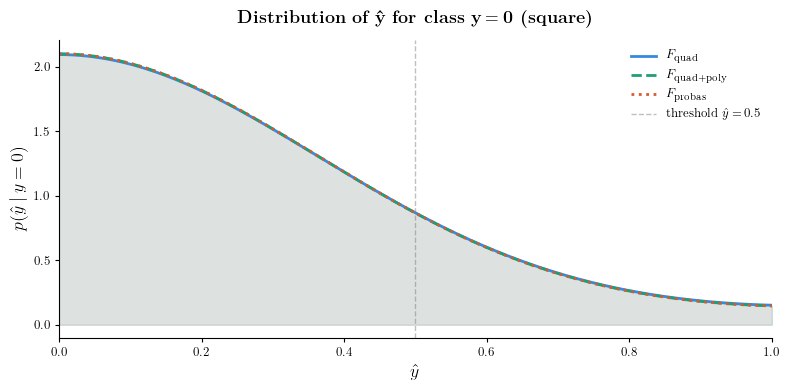

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 0
# On limite strictement l'axe des x de 0 à 1
x = np.linspace(0, 1, 300)

configs = [
    (Y_pred_quad[mask, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    # 1. MÉTHODE DES REFLETS : On ajoute les données miroir en 0 (-data) et en 1 (2 - data)
    data_reflected = np.concatenate([data, -data, 2 - data])

    # 2. On calcule le KDE sur ces données augmentées
    kde = gaussian_kde(data_reflected, bw_method="silverman")

    # 3. On évalue sur x et on multiplie par 3 (car on a triplé la quantité de données)
    density = kde(x) * 3

    # On trace la densité corrigée
    ax.plot(x, density, color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, density, alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$ for class $\mathbf{y=0}$ (square)}", fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=0)$", fontsize=13)
ax.set_xlim(0, 1) # On verrouille visuellement entre 0 et 1
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"figs/y_0_distribution_backprop_{neural_network_quad.name}.png", bbox_inches='tight', dpi=300)
plt.show()

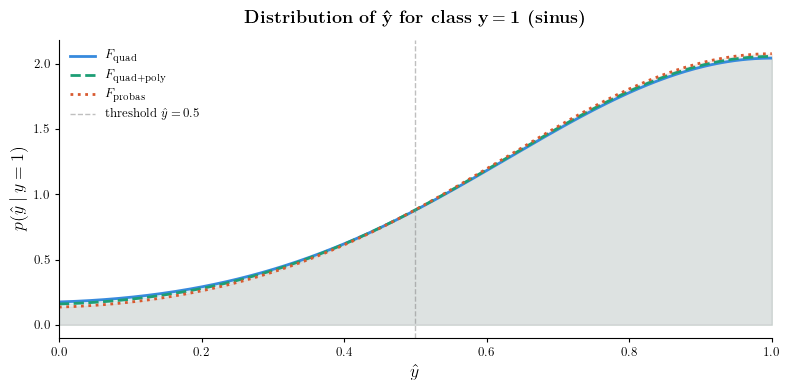

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = Y_test[:, 0] == 1
# On limite strictement l'axe des x de 0 à 1
x = np.linspace(0, 1, 300)

configs = [
    (Y_pred_quad[mask, 0],      '#378ADD', '-',  r'$F_{\mathrm{quad}}$'),
    (Y_pred_quad_poly[mask, 0], '#1D9E75', '--', r'$F_{\mathrm{quad+poly}}$'),
    (Y_pred_probas[mask, 0],    '#D85A30', ':',  r'$F_{\mathrm{probas}}$'),
]

for data, color, ls, label in configs:
    # 1. MÉTHODE DES REFLETS : On ajoute les données miroir en 0 (-data) et en 1 (2 - data)
    data_reflected = np.concatenate([data, -data, 2 - data])

    # 2. On calcule le KDE sur ces données augmentées
    kde = gaussian_kde(data_reflected, bw_method="silverman")

    # 3. On évalue sur x et on multiplie par 3 (car on a triplé la quantité de données)
    density = kde(x) * 3

    # On trace la densité corrigée
    ax.plot(x, density, color=color, ls=ls, lw=2, label=label)
    ax.fill_between(x, density, alpha=0.08, color=color)

ax.set_title(r"\textbf{Distribution of $\mathbf{\hat{y}}$ for class $\mathbf{y=1}$ (sinus)}",
             fontsize=13, pad=12)
ax.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5,
           label=r'threshold $\hat{y}=0.5$')
ax.set_xlabel(r"$\hat{y}$", fontsize=13)
ax.set_ylabel(r"$p(\hat{y} \mid y=1)$", fontsize=13)
ax.set_xlim(0, 1) # On verrouille visuellement entre 0 et 1
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

plt.savefig(f"figs/y_1_distribution_backprop_{neural_network_quad.name}.png", bbox_inches='tight', dpi=300)
plt.show()

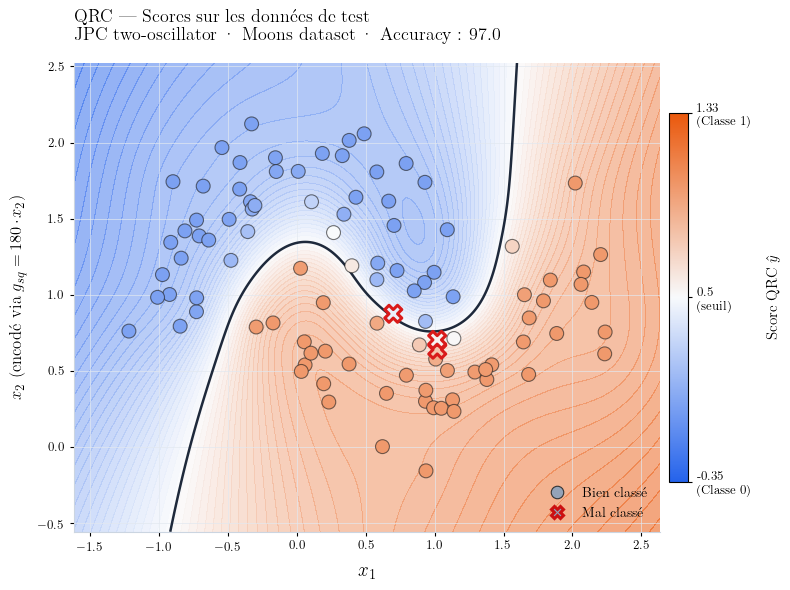

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# QRC — Visualisation sur les données de test (fond blanc + gradient RBF)
#
# Variables à brancher :
#   X_test      : shape (N, 2)
#   Y_test      : shape (N, 1) ou (N,)  — labels en {0,1} ou {-1,+1}
#   scores_test : shape (N, 1) ou (N,)  — score continu brut du readout
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator

# ── Mise à plat & normalisation des labels ───────────────────────────────────
x1 = X_test[:, 0].ravel()
x2 = X_test[:, 1].ravel()
y  = Y_test.ravel().astype(float)
s  = np.array(Y_pred_probas, dtype=float).ravel()

# Auto-détection du format de labels et du seuil de décision
if set(np.unique(y)) <= {-1., 1.}:
    threshold = 0.5
    y_bin = (y > 0).astype(int)
else:
    threshold = 0.5          # le readout QRC sort en ℝ centré sur 0
    y_bin = y.astype(int)

predicted = (s >= threshold).astype(int)
correct   = predicted == y_bin
wrong     = ~correct

# ── Gradient de fond par interpolation RBF ───────────────────────────────────
margin  = 0.4
x1g     = np.linspace(x1.min() - margin, x1.max() + margin, 300)
x2g     = np.linspace(x2.min() - margin, x2.max() + margin, 300)
xx1, xx2 = np.meshgrid(x1g, x2g)
grid    = np.c_[xx1.ravel(), xx2.ravel()]

rbf = RBFInterpolator(
    np.c_[x1, x2], s,
    kernel='thin_plate_spline', smoothing=0.5
)
Z = rbf(grid).reshape(xx1.shape)

# ── Palette (thème blanc) ─────────────────────────────────────────────────────
col0     = '#2563eb'   # bleu profond  → classe 0
col1     = '#ea580c'   # orange brûlé  → classe 1
col_mid  = '#f8fafc'   # blanc cassé   → zone de doute

cmap = LinearSegmentedColormap.from_list(
    'qrc_white',
    [(0.0, col0), (0.5, col_mid), (1.0, col1)],
    N=512
)

# Centrage de la colormap sur le seuil réel
z_min, z_max = float(Z.min()), float(Z.max())
vcenter = float(threshold)
vcenter = np.clip(vcenter, z_min + 1e-6, z_max - 1e-6)
norm_bg = TwoSlopeNorm(vmin=z_min, vcenter=vcenter, vmax=z_max)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

# Fond dégradé
ax.contourf(xx1, xx2, Z, levels=60, cmap=cmap, norm=norm_bg,
            alpha=0.55, zorder=1)

# Iso-contour au seuil de décision
ax.contour(xx1, xx2, Z, levels=[threshold],
           colors=['#1e293b'], linewidths=[1.8],
           linestyles=['-'], zorder=3)

# ── Points bien classés ───────────────────────────────────────────────────────
n_ok = int(correct.sum())
if n_ok > 0:
    ax.scatter(
        x1[correct], x2[correct],
        c=list(s[correct]),
        cmap=cmap, norm=norm_bg,
        s=100, linewidths=0.8,
        edgecolors=[(0.1, 0.1, 0.1, 0.6)] * n_ok,
        zorder=4,
    )

# ── Points mal classés ────────────────────────────────────────────────────────
n_ko = int(wrong.sum())
if n_ko > 0:
    ax.scatter(
        x1[wrong], x2[wrong],
        c=list(s[wrong]),
        cmap=cmap, norm=norm_bg,
        s=150, linewidths=2.2,
        edgecolors=[(0.85, 0.1, 0.1, 1.0)] * n_ko,
        zorder=5,
        marker='X',
    )

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_bg)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.015)
cbar.set_label('Score QRC  $\\hat{y}$', fontsize=11, labelpad=10)
cbar.ax.tick_params(labelsize=9)
tick_vals = [z_min, threshold, z_max]
tick_lbls = [f'{z_min:.2f}\n(Classe 0)', f'{threshold:.1f}\n(seuil)',
             f'{z_max:.2f}\n(Classe 1)']
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_lbls)

# ── Axes & titre ──────────────────────────────────────────────────────────────
acc = float(correct.mean()) * 100
ax.set_xlabel('$x_1$', fontsize=14, labelpad=8)
ax.set_ylabel(
    '$x_2$  (encodé via $g_{sq} = 180 \\cdot x_2$)',
    fontsize=12, labelpad=8
)
ax.set_title(
    f'QRC — Scores sur les données de test\n'
    f'JPC two-oscillator  ·  Moons dataset  ·  Accuracy : {acc:.1f} %',
    fontsize=13, fontweight='bold', pad=16, loc='left'
)
ax.tick_params(labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#cbd5e1')

# ── Légende ───────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='#94a3b8', markersize=9,
           markeredgecolor='#333333', markeredgewidth=0.8,
           label='Bien classé'),
    Line2D([0], [0], marker='X', linestyle='None',
           markerfacecolor='#94a3b8', markersize=9,
           markeredgecolor='#cc1111', markeredgewidth=2.2,
           label='Mal classé'),
]
ax.legend(handles=legend_elements, loc='lower right',
          framealpha=0.85, fontsize=10)

ax.grid(True, color='#e2e8f0', linewidth=0.6, alpha=0.8, zorder=0)
plt.tight_layout()
plt.savefig('qrc_test_scatter.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()